# Notebook 1 — Model Setup & Exogenous Paths

This notebook sets up the **two-country OLG model** from `Corollary_V3.tex`:
- Load shared module (`TwoCountryOLG.jl`)
- Display calibrated parameters with literature sources
- Validate parameter constraints (Lemma 1)
- Generate and visualise exogenous paths of endowments and dividends

In [2]:
# ── Activate project environment ──
using Pkg
Pkg.activate(".")
Pkg.add("DifferentiationInterface")


# ── Load shared module ──
include("TwoCountryOLG.jl")

using Plots, LaTeXStrings, Printf
gr()   # GR backend for fast rendering

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT`
    Updating registry at `~/.julia/registries/General`
┌ Info: The General registry is installed via git. Consider reinstalling it via
│ the newer faster direct from tarball format by running:
│   pkg> registry rm General; registry add General
│ 
└ @ Pkg.Registry /Users/jipengcheng/.julia/juliaup/julia-1.12.1+0.aarch64.apple.darwin14/share/julia/stdlib/v1.12/Pkg/src/Registry/Registry.jl:483
    Updating git-repo `https://github.com/JuliaRegistries/General.git`
   Resolving package versions...
   Installed libdecor_jll ───────────────── v0.2.2+0
   Installed libfdk_aac_jll ─────────────── v2.0.4+0
   Installed x265_jll ───────────────────── v4.1.0+0
   Installed JpegTurbo_jll ──────────────── v3.1.4+0
   Installed LERC_jll ───────────────────── v4.0.1+0
   Installed Libmount_jll ───────────────── v2.41.3+0
   Installed Preferences ────────────────── v1.5.2
   Installed Opus_jll ──────────────────

Plots.GRBackend()

## 1. Baseline Parameters

Each OLG period represents **5 years**. Growth rates are compounded to per-period values.

| Parameter | Symbol | Baseline | Source |
|-----------|--------|----------|--------|
| Discount factor | $\beta$ | 0.50 | Saving propensity out of young-age income |
| Risk aversion | $\gamma$ | 2.0 | Macro-finance consensus |
| Home-bias cost | $\kappa$ | 0.01 | Coeurdacier & Rey (2013) |
| Convenience yield | $\chi$ | 0.03 | Krishnamurthy & Vissing-Jorgensen (2012) |
| Bond-cost scaling | $\eta$ | 0.01 | Model-specific friction |
| US home-bias target | $\bar\omega$ | 0.80 | French & Poterba (1991) |
| RoW US-equity target | $\bar\omega^*$ | 0.20 | ECB data on foreign holdings |
| Regime persistence | $\pi$ | 0.70 | Hamilton (1989); Guerron-Quintana et al. (2023) |
| US endowment growth (state $u$) | $g_{e,u}$ | $1.035^{5} \approx 1.188$ | 3.5% annual, 5-yr compound |
| US dividend growth (state $u$) | $g_{D,u}$ | $1.015^{5} \approx 1.077$ | 1.5% annual, 5-yr compound |
| Balanced / RoW growth | $g_b$ | $1.02^{5} \approx 1.104$ | 2% annual, 5-yr compound |
| Initial dividend-to-endowment | $D/e$ | 0.04 | NIPA / FRED data |
| Horizon | $T_{\max}$ | 120 | 120 five-year periods (600 years) |

In [3]:
# ── Construct baseline parameters ──
p = ModelParams()

println("═══ Baseline Calibration ═══")
@printf("  β  = %.2f\n", p.β)
@printf("  γ  = %.1f\n", p.γ)
@printf("  κ  = %.4f\n", p.κ)
@printf("  χ  = %.4f\n", p.χ)
@printf("  η  = %.4f\n", p.η)
@printf("  ω̄  = %.2f\n", p.ω̄)
@printf("  ω̄* = %.2f\n", p.ω̄_star)
@printf("  π  = %.2f  ⟹  E[τ] = %.1f periods (= %.0f years)\n",
        p.π_persist, 1/(1-p.π_persist), 5/(1-p.π_persist))
@printf("  g_e_u = 1.035^5 = %.4f  (3.5%% annual)\n", p.g_e_u)
@printf("  g_D_u = 1.015^5 = %.4f  (1.5%% annual)\n", p.g_D_u)
@printf("  g_b   = 1.02^5  = %.4f  (2.0%% annual)\n", p.g_e_b)
@printf("  D/e₀  = %.2f\n", p.D_e_ratio_0)
@printf("  T_max = %d periods (= %d years)\n", p.T_max, p.T_max * 5)

═══ Baseline Calibration ═══
  β  = 0.50
  γ  = 0.5
  κ  = 0.0100
  χ  = 0.0300
  η  = 0.0100
  ω̄  = 0.80
  ω̄* = 0.20
  π  = 0.70  ⟹  E[τ] = 3.3 periods (= 17 years)
  g_e_u = 1.035^5 = 1.1877  (3.5% annual)
  g_D_u = 1.015^5 = 1.0773  (1.5% annual)
  g_b   = 1.02^5  = 1.1041  (2.0% annual)
  D/e₀  = 0.04
  T_max = 120 periods (= 600 years)


In [4]:
# ── Validate constraints ──
validate_params(p)
println("✓ All parameter constraints satisfied.")
@printf("  Lemma 1 check: κ = %.4f < β/ω̄ = %.4f  ✓\n", p.κ, p.β / p.ω̄)

✓ All parameter constraints satisfied.
  Lemma 1 check: κ = 0.0100 < β/ω̄ = 0.6250  ✓


## 2. Generate Exogenous Paths

Along the $u$-history (unbalanced growth), the US endowment grows at $g_{e,u}$ while US dividends grow at $g_{D,u} < g_{e,u}$.  
The RoW is always on its balanced growth path: both endowment and dividends grow at $g_b$.

The key feature is that $D_{US,t}/e_{US,t} \to 0$ geometrically, which is necessary for bubble existence (Corollary 1, condition 2a).

In [5]:
paths = generate_exogenous_paths(p)

println("Exogenous paths generated: T = $(paths.T) periods ($(paths.T * 5) years)")
@printf("  e_US[1] = %.4f,  e_US[T] = %.4e\n", paths.e_US[1], paths.e_US[end])
@printf("  D_US[1] = %.4f,  D_US[T] = %.4e\n", paths.D_US[1], paths.D_US[end])
@printf("  D/e ratio at t=1:  %.4f\n", paths.D_US[1]/paths.e_US[1])
@printf("  D/e ratio at t=T:  %.4e\n", paths.D_US[end]/paths.e_US[end])
@printf("  Geometric decay factor per period: g_D/g_e = %.6f\n", p.g_D_u / p.g_e_u)
@printf("  Country size ε = e_W/e_US at T: %.6f\n", paths.e_W[end] / paths.e_US[end])

Exogenous paths generated: T = 121 periods (605 years)
  e_US[1] = 1.0000,  e_US[T] = 9.2089e+08
  D_US[1] = 0.0400,  D_US[T] = 3.0317e+02
  D/e ratio at t=1:  0.0400
  D/e ratio at t=T:  3.2921e-07
  Geometric decay factor per period: g_D/g_e = 0.907044
  Country size ε = e_W/e_US at T: 0.000157


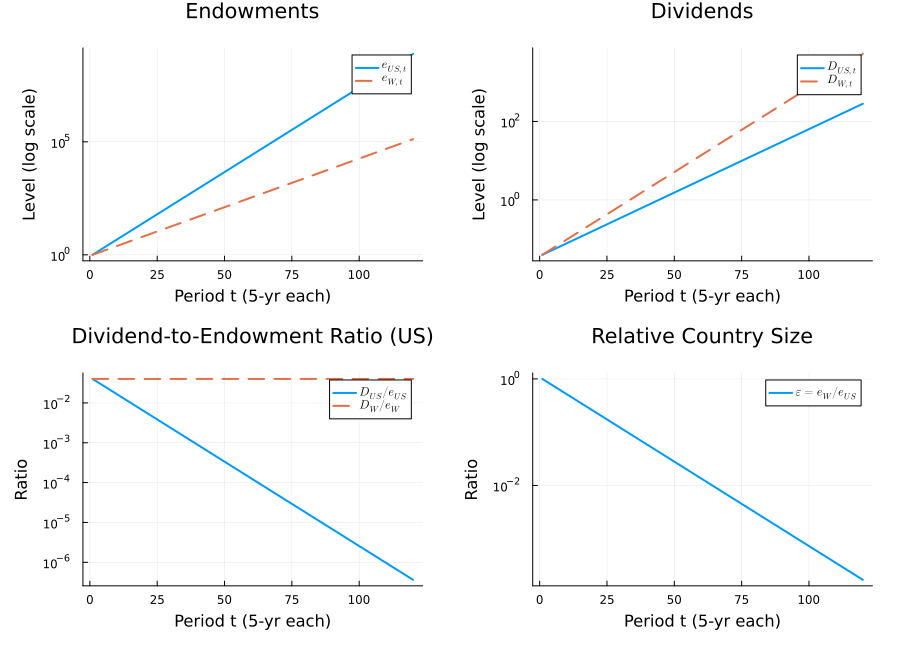

In [6]:
# ── Plot exogenous paths (log scale) ──
T = p.T_max
tt = 1:T

p1 = plot(tt, paths.e_US[1:T], label=L"e_{US,t}", lw=2, yscale=:log10,
          xlabel="Period t (5-yr each)", ylabel="Level (log scale)",
          title="Endowments")
plot!(p1, tt, paths.e_W[1:T], label=L"e_{W,t}", lw=2, ls=:dash)

p2 = plot(tt, paths.D_US[1:T], label=L"D_{US,t}", lw=2, yscale=:log10,
          xlabel="Period t (5-yr each)", ylabel="Level (log scale)",
          title="Dividends")
plot!(p2, tt, paths.D_W[1:T], label=L"D_{W,t}", lw=2, ls=:dash)

p3 = plot(tt, paths.D_US[1:T] ./ paths.e_US[1:T], label=L"D_{US}/e_{US}", lw=2,
          xlabel="Period t (5-yr each)", ylabel="Ratio",
          title="Dividend-to-Endowment Ratio (US)", yscale=:log10)
plot!(p3, tt, paths.D_W[1:T] ./ paths.e_W[1:T], label=L"D_W/e_W", lw=2, ls=:dash)

p4 = plot(tt, paths.e_W[1:T] ./ paths.e_US[1:T], label=L"\varepsilon = e_W/e_{US}", lw=2,
          xlabel="Period t (5-yr each)", ylabel="Ratio",
          title="Relative Country Size", yscale=:log10)

plot(p1, p2, p3, p4, layout=(2,2), size=(900, 650), margin=5Plots.mm)

## 3. Summability Check (Corollary 1, Condition 2a — Exogenous)

Condition (2a): $\sum_{t=1}^\infty D_t^u / e_{US,t}^u < \infty$.  
Since $D_t^u / e_{US,t}^u = (D/e)_0 \cdot (g_{D,u}/g_{e,u})^{t-1}$, this is a geometric series converging iff $g_{D,u} < g_{e,u}$.

Geometric ratio g_D/g_e = 0.907044  (< 1 ⟹ converges)
Analytical infinite sum  = 0.430312
Partial sum at T=120     = 0.430309  (100.00% of ∞-sum)


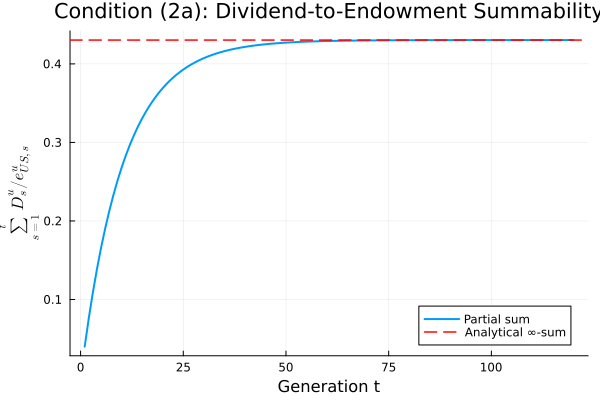

In [7]:
de_ratio = paths.D_US[1:T] ./ paths.e_US[1:T]
cum_de   = cumsum(de_ratio)

# Analytical sum of infinite geometric series
r_geom = p.g_D_u / p.g_e_u
analytical_sum = p.D_e_ratio_0 / (1 - r_geom)

@printf("Geometric ratio g_D/g_e = %.6f  (< 1 ⟹ converges)\n", r_geom)
@printf("Analytical infinite sum  = %.6f\n", analytical_sum)
@printf("Partial sum at T=%d     = %.6f  (%.2f%% of ∞-sum)\n",
        T, cum_de[end], 100*cum_de[end]/analytical_sum)

plot(tt, cum_de, lw=2, label="Partial sum",
     xlabel="Generation t", ylabel=L"\sum_{s=1}^t D_s^u / e_{US,s}^u",
     title="Condition (2a): Dividend-to-Endowment Summability")
hline!([analytical_sum], ls=:dash, lw=1.5, lc=:red, label="Analytical ∞-sum")

## Summary

- Parameters validated: all constraints from the model (Lemma 1, positivity, etc.) are satisfied.
- Each OLG period represents **5 years**; the horizon is $T_{\max} = 120$ periods (600 years).
- Exogenous paths generated: US endowment growth (3.5%/yr) outpaces US dividends (1.5%/yr) and RoW (2.0%/yr).
- The dividend-to-endowment ratio $D_{US,t}^u / e_{US,t}^u$ decays geometrically, so **Condition (2a) is satisfied** — a necessary condition for bubbles.
- The relative country size $\varepsilon = e_W/e_{US}$ declines over time because the US grows faster in state $u$.

**Next**: Notebook 02 solves the balanced-growth (state $b$) equilibrium.